In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score, roc_curve, auc


In [2]:
data = pd.read_csv('/content/Telco_Customer_Churn.csv')
data.shape

(7043, 21)

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
original_rows = len(data)
data = data.dropna(subset=['TotalCharges'])
print(f"Total dropped rows with NaNs: {original_rows - len(data)}")

Total dropped rows with NaNs: 11


In [6]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [8]:
X = data[numeric_features + categorical_features]
y = data[target_feature]

In [9]:
from collections import Counter
Counter(y)
#The data is imbalanced since yes and no are not 50-50

Counter({'No': 5163, 'Yes': 1869})

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify=y)
#In train_test_split, the stratify parameter ensures that the proportions of class labels in the training and testing sets are approximately the same as the proportions in the original dataset.

In [11]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})
y = y.map({'Yes': 1, 'No': 0})


In [12]:
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Original data churn rate: 0.27
Training data churn rate: 0.27
Testing data churn rate: 0.27


In [13]:
from sklearn.compose import ColumnTransformer
# Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical Preprocessing Batch

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)

    ],
    remainder = 'drop'
)

# Create the final, full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        random_state = 42,

    ))
])


In [14]:
clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [15]:
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[0 0 1 ... 1 0 0]


In [16]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)


[0.06421    0.07123252 0.68790832 ... 0.71182561 0.37556155 0.33472347]


In [17]:
print(recall_score(y_test, y_predict))


0.7932263814616756


In [18]:
print(confusion_matrix(y_test, y_predict))

[[1146  403]
 [ 116  445]]


In [19]:
print(precision_score(y_test, y_predict))

0.5247641509433962


In [20]:
print(accuracy_score(y_test, y_predict))

0.7540284360189573


In [21]:
print(f1_score(y_test, y_predict))

0.631653655074521


In [22]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1549
           1       0.52      0.79      0.63       561

    accuracy                           0.75      2110
   macro avg       0.72      0.77      0.72      2110
weighted avg       0.81      0.75      0.77      2110



In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8436401381375369


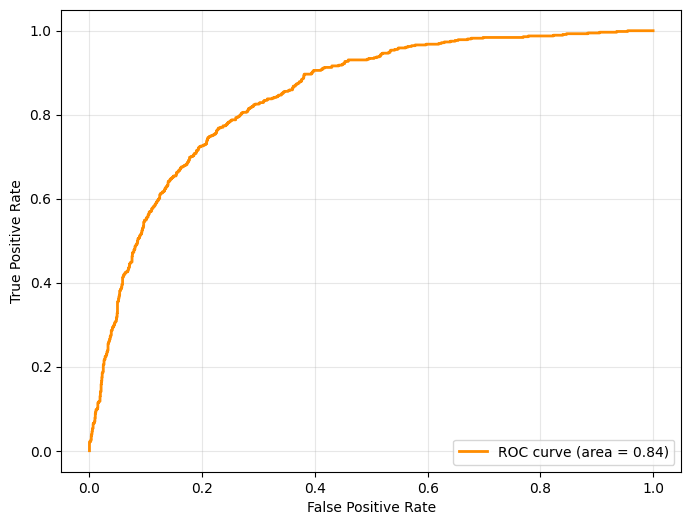

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [25]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators = 200,
        class_weight = 'balanced',
        random_state = 42,

    ))
])

In [26]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [27]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [28]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.63      0.48      0.54       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



In [29]:
print(confusion_matrix(y_test, y_pred_rf))

[[1391  158]
 [ 294  267]]


In [30]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.8142651978333444


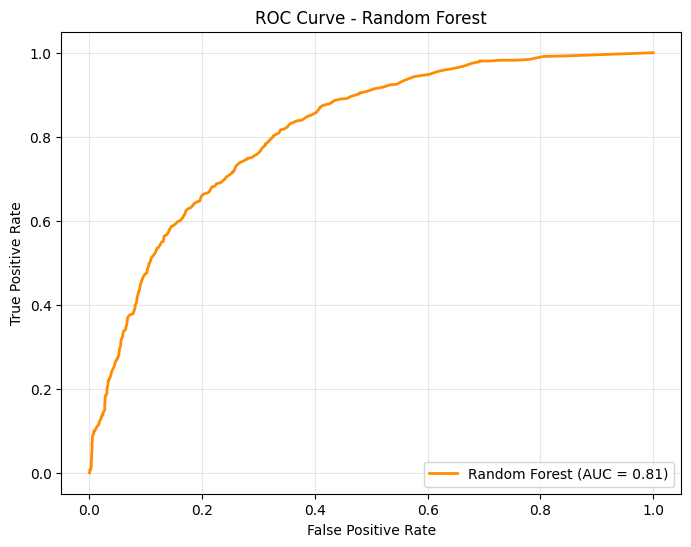

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.8445185622773745


In [33]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8247964080538814


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [35]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'tenure']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='i...
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 5],
                         'model__min_samples_split': [2, 10],
                         'model__n_estimators': [200, 400]},
             scoring='roc_auc', verbose=2)

In [36]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC: 0.8428780505736987


In [37]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


0.8445325544972376
0.7791469194312797
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1549
           1       0.57      0.73      0.64       561

    accuracy                           0.78      2110
   macro avg       0.73      0.76      0.74      2110
weighted avg       0.80      0.78      0.79      2110



In [38]:

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
37,cat__Contract_Month-to-month,0.133271
2,num__tenure,0.123819
1,num__TotalCharges,0.099659
0,num__MonthlyCharges,0.070730
39,cat__Contract_Two year,0.065541
19,cat__OnlineSecurity_No,0.055166
17,cat__InternetService_Fiber optic,0.048590
28,cat__TechSupport_No,0.045220
44,cat__PaymentMethod_Electronic check,0.028331
38,cat__Contract_One year,0.022521


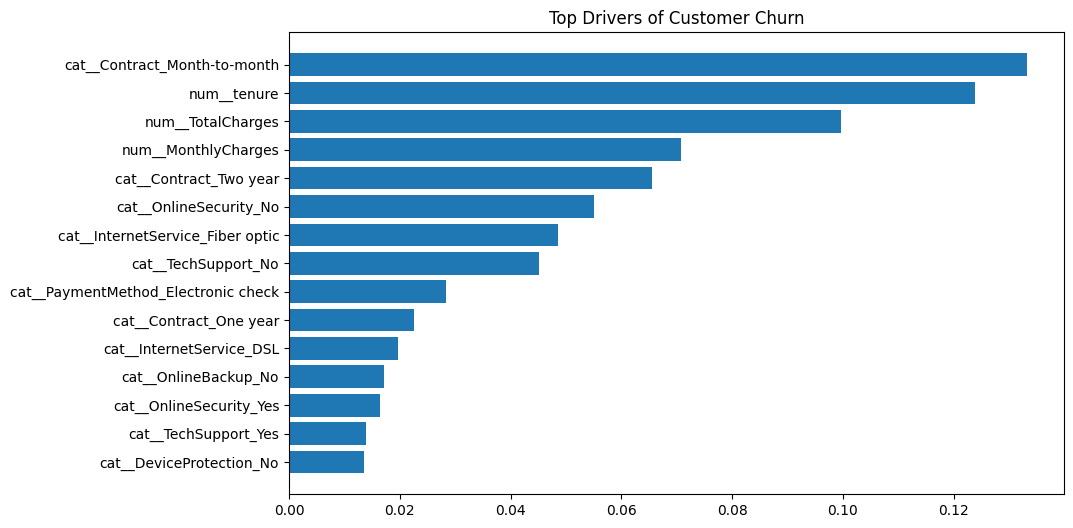

In [39]:

top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [40]:

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.10,0.345000,0.983957,0.510875
1,0.15,0.370979,0.966132,0.536103
2,0.20,0.399251,0.950089,0.562236
3,0.25,0.424837,0.926916,0.582633
4,0.30,0.447415,0.894831,0.596554
5,0.35,0.475767,0.857398,0.611959
6,0.40,0.507625,0.830660,0.630156
7,0.45,0.529625,0.780749,0.631124
8,0.50,0.565517,0.730838,0.637636
9,0.55,0.587349,0.695187,0.636735


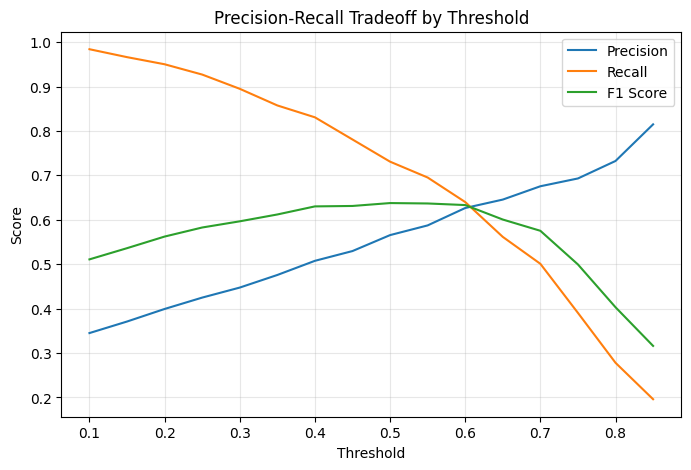

In [41]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()

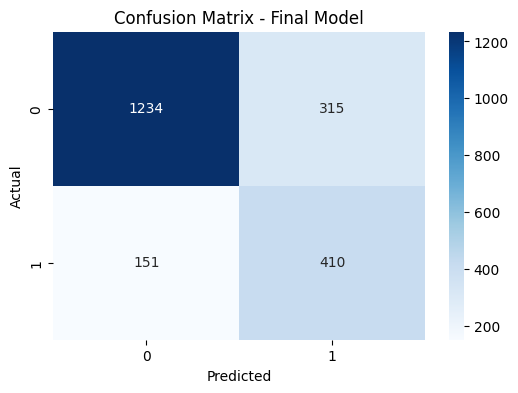

In [42]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

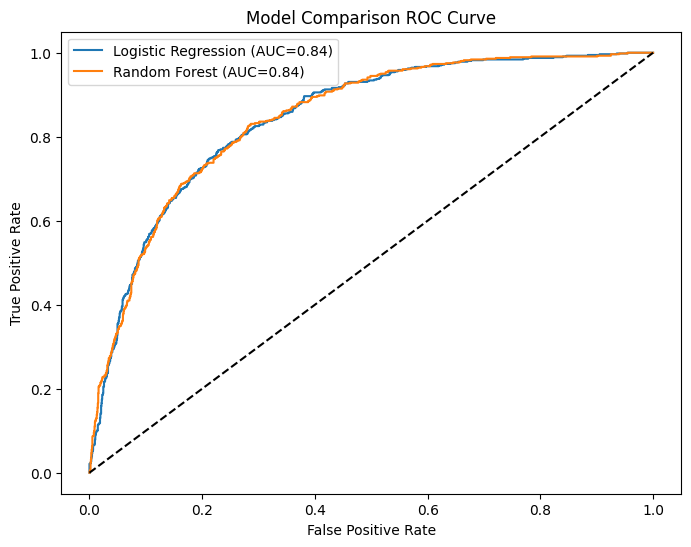

In [43]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [44]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df["risk_level"].value_counts()

,count
risk_level,
Low Risk,988
High Risk,573
Medium Risk,549


In [45]:
import joblib

joblib.dump(clf_pipeline, "logistic_model.pkl")
joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

In [46]:
import sklearn
print(sklearn.__version__)

1.6.1
